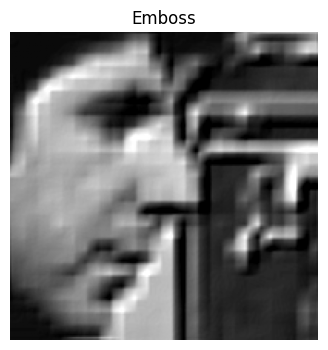

Dropdown(description='Filter:', index=4, options=('Original', 'Sharpen', 'Blur', 'Edge Detection', 'Emboss'), …

Button(description='Proses', style=ButtonStyle())

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================
# UPLOAD GAMBAR
# =========================
uploaded = files.upload()

# baca gambar
img = cv2.imread(list(uploaded.keys())[0])
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# FUNGSI CONVOLUTION
# =========================
def apply_filter(filter_type):
    if filter_type == "Original":
        return img_gray

    elif filter_type == "Sharpen":
        kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])

    elif filter_type == "Blur":
        kernel = np.ones((3,3), np.float32) / 9

    elif filter_type == "Edge Detection":
        kernel = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]])

    elif filter_type == "Emboss":
        kernel = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])

    return cv2.filter2D(img_gray, -1, kernel)

# =========================
# PROSES GUI
# =========================
def process_image(b):
    clear_output(wait=True)

    result = apply_filter(dropdown.value)

    plt.figure(figsize=(5,4))
    plt.title(dropdown.value)
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.show()

    display(dropdown, button)

# =========================
# WIDGET GUI
# =========================
dropdown = widgets.Dropdown(
    options=["Original", "Sharpen", "Blur", "Edge Detection", "Emboss"],
    description='Filter:',
)

button = widgets.Button(description="Proses")

button.on_click(process_image)

display(dropdown, button)